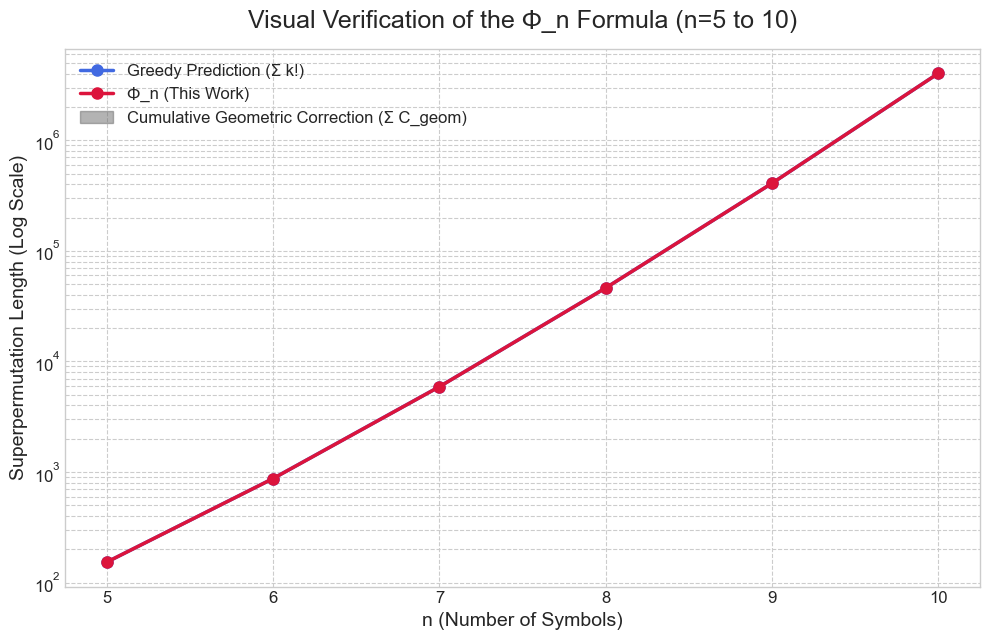

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- Core functions from the paper ---
def factorial_sum(n):
    """Calculates the length predicted by the Greedy algorithm, Σ_{k=1 to n} k!."""
    s = 0
    current_factorial = 1
    for k in range(1, n + 1):
        current_factorial *= k
        s += current_factorial
    return s

def C_geom(n):
    """Calculates the Geometric Correction Term, C_geom(n)."""
    if n < 6:
        return 0
    return (n - 4) * (3 * n - 17) // 2

def Phi_n(n):
    """Calculates the final formula for the minimal superpermutation length, Φ_n."""
    greedy_length = factorial_sum(n)
    total_correction = 0
    for k in range(6, n + 1):
        total_correction += C_geom(k)
    return greedy_length - total_correction

# --- Generate data for the plot ---
n_range = np.arange(5, 11)
greedy_values = [factorial_sum(n) for n in n_range]
phi_values = [Phi_n(n) for n in n_range]

# --- Create the plot (Figure 4) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6.5))

# Plot the two lines
ax.plot(n_range, greedy_values, 'o-', label='Greedy Prediction (Σ k!)', color='royalblue', linewidth=2.5, markersize=8)
ax.plot(n_range, phi_values, 'o-', label='Φ_n (This Work)', color='crimson', linewidth=2.5, markersize=8)

# Highlight the area between the lines
ax.fill_between(n_range, greedy_values, phi_values, color='dimgray', alpha=0.5, label='Cumulative Geometric Correction (Σ C_geom)')

# Set labels, title, legend, etc.
ax.set_xlabel('n (Number of Symbols)', fontsize=14)
ax.set_ylabel('Superpermutation Length (Log Scale)', fontsize=14)
ax.set_title('Visual Verification of the Φ_n Formula (n=5 to 10)', fontsize=18, pad=15)
ax.legend(fontsize=12, loc='upper left')
ax.set_xticks(n_range)

# Format y-axis with commas
ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
ax.tick_params(axis='both', which='major', labelsize=12)

# Use a logarithmic scale for the y-axis to effectively visualize the rapid growth
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.tight_layout()

# Save the figure and show the plot
# plt.savefig('figure_4_visual_verification_EN.png', dpi=300)
plt.show()
